# Problem Statement **1**



# API Data Retrieval and Storage



In [ ]:
# API Data Retrieval and Storage: You are tasked with fetching data from an external REST API, storing it in a local SQLite database, and displaying the retrieved data. The API provides a list of books in JSON format with attributes like title, author, and publication year.
# 1.


import requests, sqlite3 #to make HTTP calls

#Setting up the Database....
conn = sqlite3.connect('books.db')
cursor = conn.cursor()
cursor.execute('''
    CREATE TABLE IF NOT EXISTS books (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        title TEXT NOT NULL,
        author TEXT,
        publication_year INTEGER,
        UNIQUE(title, author)
    )
''')
conn.commit()

# --- Fetch from Google Books API  ---
url = "https://www.googleapis.com/books/v1/volumes?q=fiction&maxResults=20"
response = requests.get(url, timeout=10)
response.raise_for_status()
data = response.json()   # It

# --- Parsing and Insertion ---
for item in data.get('items', []):
    info   = item.get('volumeInfo', {})
    title  = info.get('title', 'Unknown')
    authors = info.get('authors', ['Unknown'])
    author = authors[0]
    date   = info.get('publishedDate', '')
    year   = int(date[:4]) if date and date[:4].isdigit() else None

    cursor.execute(
        'INSERT OR IGNORE INTO books (title, author, publication_year) VALUES (?, ?, ?)',
        (title, author, year)
    )

conn.commit()

# --- Display ---
print(f"{'Title':<50} {'Author':<25} {'Year'}")
print('-' * 85)
for row in cursor.execute('SELECT title, author, publication_year FROM books'):
    print(f"{row[0]:<50} {row[1]:<25} {str(row[2]) if row[2] else 'N/A'}")

conn.close()

Title                                              Author                    Year
-------------------------------------------------------------------------------------
Frankenstein; or, the modern prometheus            Shelley, Mary Wollstonecraft 1797
Wuthering Heights                                  Brontë, Emily             1818
Moby Dick; Or, The Whale                           Melville, Herman          1819
Pride and Prejudice                                Austen, Jane              1775
Romeo and Juliet                                   Shakespeare, William      1564
The Complete Works of William Shakespeare          Shakespeare, William      1564
Alice's Adventures in Wonderland                   Carroll, Lewis            1832
Simple Sabotage Field Manual                       United States. Office of Strategic Services N/A
The strange case of Dr. Jekyll and Mr. Hyde        Stevenson, Robert Louis   1850
Middlemarch                                        Eliot, George          

# Data Processing and Visualization

📡 Fetching student data from DummyJSON API...
✅ Successfully fetched 15 students!

         📊 CLASS STATISTICS SUMMARY
  Total Students  : 15
  Class Average   : 71.0 / 100
  Highest Score   : 99  (William Gonzalez)
  Lowest Score    : 49  (Charlotte Lopez)
  Pass Rate       : 80.0%  (12/15 students)

📋 STUDENT SCORE TABLE
------------------------------------------------------------
                 Name  Age  Score Grade
1    William Gonzalez   33     99    A+
2         Emma Miller   31     98    A+
3        Sophia Brown   43     87     A
4    Michael Williams   36     82     A
5       Emily Johnson   29     77     B
6         Liam Garcia   30     71     B
7   Isabella Anderson   32     68     C
8          Ava Taylor   28     67     C
9     Alexander Jones   39     66     C
10     Ethan Martinez   34     65     C
11        James Davis   46     64     C
12     Noah Hernandez   41     60     C
13      Olivia Wilson   23     59     D
14      Mia Rodriguez   25     53     D
15    Charlott

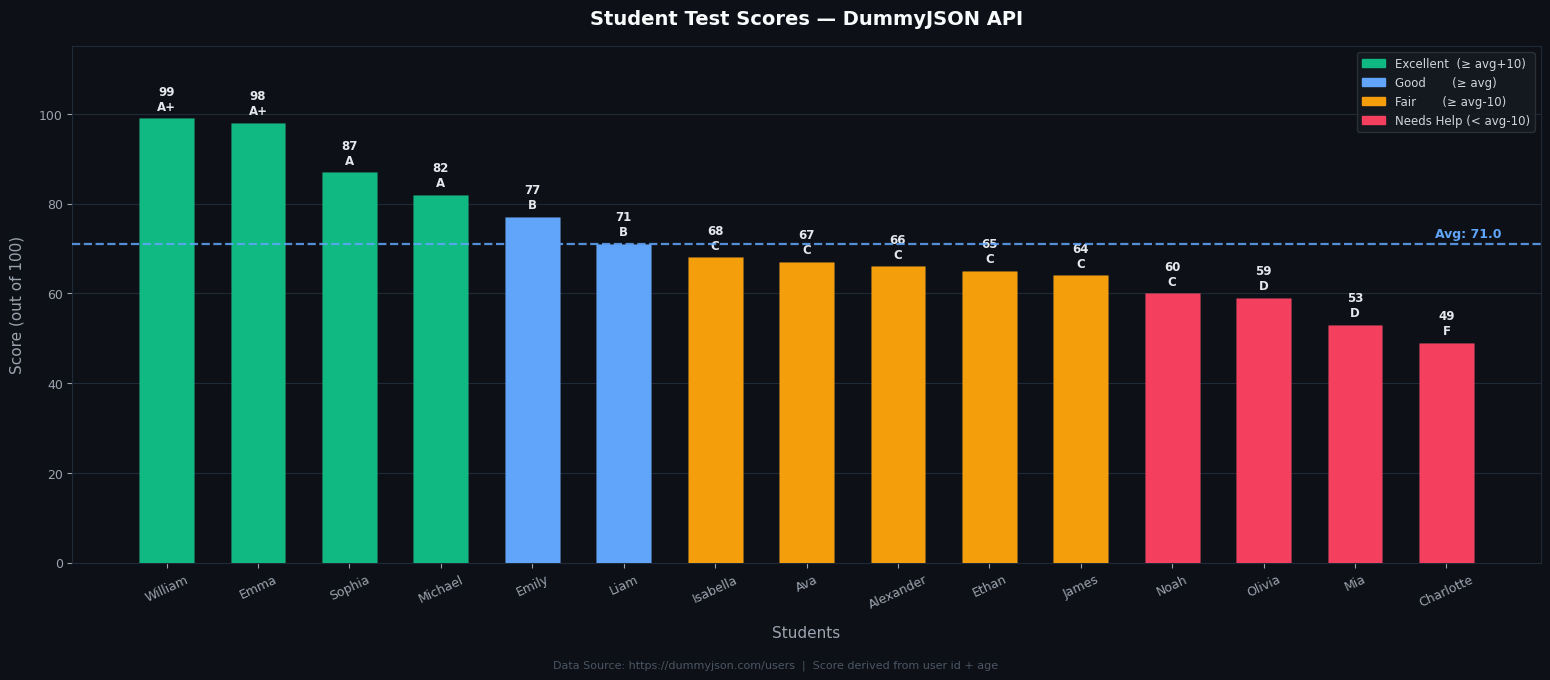


✅ Chart saved as 'student_scores.png'


In [ ]:
# ============================================================
#   Student Test Score Dashboard — Google Colab
#   API: https://dummyjson.com/users
# ============================================================

# ── Step 1: Import libraries ─────────────────────────────────
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mp
import numpy as np

# ── Step 2: Fetch data from DummyJSON API ───────────────────
print("📡 Fetching student data from DummyJSON API...")

url = "https://dummyjson.com/users?limit=15&select=firstName,lastName,age,university,email"
response = requests.get(url)

if response.status_code == 200:
    users = response.json()["users"]
    print(f"✅ Successfully fetched {len(users)} students!\n")
else:
    raise Exception(f"❌ API request failed with status code {response.status_code}")

# ── Step 3: Process data ─────────────────────────────────────
# Score is deterministically generated from id + age (no gpa field in API)
def generate_score(user_id, age):
    seed = (user_id * 17 + age * 7) % 61   # gives range 0–60
    return seed + 40                         # final range: 40–100

students = []
for i, u in enumerate(users):
    score = generate_score(i + 1, u["age"])
    students.append({
        "Name":        f"{u['firstName']} {u['lastName']}",
        "First Name":   u["firstName"],
        "Age":          u["age"],
        "Score":        score,
        "University":   u.get("university", "N/A"),
        "Email":        u.get("email", "N/A"),
    })

df = pd.DataFrame(students)

# ── Step 4: Calculate statistics ────────────────────────────
avg_score   = round(df["Score"].mean(), 2)
max_score   = df["Score"].max()
min_score   = df["Score"].min()
top_student = df.loc[df["Score"].idxmax(), "Name"]
low_student = df.loc[df["Score"].idxmin(), "Name"]
pass_count  = len(df[df["Score"] >= 60])
pass_rate   = round((pass_count / len(df)) * 100, 1)

print("=" * 50)
print("         📊 CLASS STATISTICS SUMMARY")
print("=" * 50)
print(f"  Total Students  : {len(df)}")
print(f"  Class Average   : {avg_score} / 100")
print(f"  Highest Score   : {max_score}  ({top_student})")
print(f"  Lowest Score    : {min_score}  ({low_student})")
print(f"  Pass Rate       : {pass_rate}%  ({pass_count}/{len(df)} students)")
print("=" * 50)

# ── Step 5: Assign grade labels & colors ─────────────────────
def get_grade(score):
    if score >= 90:   return "A+"
    elif score >= 80: return "A"
    elif score >= 70: return "B"
    elif score >= 60: return "C"
    elif score >= 50: return "D"
    else:             return "F"

def get_color(score, avg):
    if score >= avg + 10:   return "#10b981"  # green  — excellent
    elif score >= avg:      return "#60a5fa"  # blue   — good
    elif score >= avg - 10: return "#f59e0b"  # amber  — fair
    else:                   return "#f43f5e"  # red    — needs help

df["Grade"] = df["Score"].apply(get_grade)
df["Color"] = df["Score"].apply(lambda s: get_color(s, avg_score))

# Sort by score descending for chart
df_sorted = df.sort_values("Score", ascending=False).reset_index(drop=True)

# ── Step 6: Print full student table ─────────────────────────
print("\n📋 STUDENT SCORE TABLE")
print("-" * 60)
display_df = df_sorted[["Name", "Age", "Score", "Grade"]].copy()
display_df.index = range(1, len(display_df) + 1)
print(display_df.to_string())
print("-" * 60)

# ── Step 7: Plot Bar Chart ───────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor("#0d1117")
ax.set_facecolor("#0d1117")

bars = ax.bar(
    df_sorted["First Name"],
    df_sorted["Score"],
    color=df_sorted["Color"],
    width=0.6,;    zorder=3,
    edgecolor="#ffffff10",
    linewidth=0.5
)

# Score labels on top of bars
for bar, score, grade in zip(bars, df_sorted["Score"], df_sorted["Grade"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.2,
        f"{score}\n{grade}",
        ha="center", va="bottom",
        fontsize=8.5, color="#e5e7eb",
        fontweight="bold"
    )

# Average reference line
ax.axhline(avg_score, color="#60a5fa", linewidth=1.6,
           linestyle="--", zorder=4, alpha=0.85)
ax.text(len(df_sorted) - 0.4, avg_score + 1.5,
        f"Avg: {avg_score}", color="#60a5fa",
        fontsize=9, fontweight="bold", ha="right")

# Styling
ax.set_ylim(0, 115)
ax.set_xlabel("Students", color="#9ca3af", fontsize=11, labelpad=10)
ax.set_ylabel("Score (out of 100)", color="#9ca3af", fontsize=11, labelpad=10)
ax.set_title("Student Test Scores — DummyJSON API",
             color="#f9fafb", fontsize=14, fontweight="bold", pad=16)
ax.tick_params(axis="x", colors="#9ca3af", rotation=25, labelsize=9)
ax.tick_params(axis="y", colors="#9ca3af", labelsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor("#1f2937")
ax.yaxis.grid(True, color="#1f2937", linestyle="-", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

# Legend — using mp.Patch (matplotlib.patches as mp)
legend_items = [
    mp.Patch(color="#10b981", label="Excellent  (≥ avg+10)"),
    mp.Patch(color="#60a5fa", label="Good       (≥ avg)"),
    mp.Patch(color="#f59e0b", label="Fair       (≥ avg-10)"),
    mp.Patch(color="#f43f5e", label="Needs Help (< avg-10)"),
]
ax.legend(handles=legend_items, loc="upper right",
          facecolor="#161b22", edgecolor="#30363d",
          labelcolor="#d1d5db", fontsize=8.5)

# ── Footer ───────────────────────────────────────────────────
fig.text(0.5, 0.01,
         "Data Source: https://dummyjson.com/users  |  Score derived from user id + age",
         ha="center", color="#4b5563", fontsize=8)

plt.tight_layout(pad=2.5)
plt.savefig("student_scores.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("\n✅ Chart saved as 'student_scores.png'")